<a href="https://colab.research.google.com/github/MarcellaAriani/Eksplorasi-n-Visualisasi-Data/blob/main/Tugas%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Analisis Sentimen Aplikasi TikTok** ##

In [4]:
# Biodata

nama = "Marcella Ariani"
nim = 20254920003
prodi = "Statistika"

print("Nama  :", nama)
print("NIM   :", nim)
print("Prodi :", prodi)

Nama  : Marcella Ariani
NIM   : 20254920003
Prodi : Statistika


### **Install & Import Dependencies** ###

In [5]:
# Install required libraries (if not installed)
!pip install pandas google-play-scraper

# Import necessary libraries
from urllib.parse import urlparse, parse_qs
from google_play_scraper import reviews, Sort
import pandas as pd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00


### **Extract Package Name from Google Play URL** ###

In [6]:
# Function to extract package name from Google Play URL
def get_package_name(play_store_url):
    parsed_url = urlparse(play_store_url)
    query_params = parse_qs(parsed_url.query)
    return query_params.get('id', [None])[0]

# Define Google Play Store URL
url = "https://play.google.com/store/apps/details?id=com.ss.android.ugc.trill&hl=id"

# Extract package name
package_name = get_package_name(url)
print("Extracted Package Name:", package_name)

Extracted Package Name: com.ss.android.ugc.trill


### **Fetch Google Play Reviews** ###

In [8]:
# Fetch reviews using the extracted package name
app_reviews, _ = reviews(
    package_name,
    lang='id',   # Language: Indonesia
    country='id',  # Country: Indonesian
    count= 10000,   # Fetch 10000 reviews to allow filtering
    sort= Sort.NEWEST  # Get the latest reviews
)

# Convert reviews to a DataFrame
df = pd.DataFrame(app_reviews)

# Display
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c4dfc473-5995-4102-87c8-b84052619c51,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,semakin di update semakin ngeleg,3,0,None,2026-05-13 15:34:58,"Hai, terima kasih atas umpan balikmu!\nKami pa...",2026-05-13 16:00:10,None
1,3c0aea63-9c1e-4693-b282-b1fa99c5b26e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tiktok alay,1,0,44.8.3,2026-05-13 15:32:47,"Hai, terima kasih atas umpan balikmu!\nKami pa...",2026-05-13 16:00:12,44.8.3
2,2a75957f-3595-4750-86a1-c10af95304d1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"assalamualaikum google, hallo tik tok semoga k...",5,0,43.1.4,2026-05-13 15:29:01,Hai! Terima kasih telah meluangkan waktu untuk...,2026-05-13 15:40:11,43.1.4
3,2aa208c9-3079-4f3c-98a1-897d39d5049e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,cara VN gimana nanya doang plssss aku pengen v...,4,0,45.0.3,2026-05-13 15:26:45,"Hai, terima kasih atas umpan balikmu!\nKami pa...",2026-05-13 15:40:11,45.0.3
4,f6298f46-e6f2-4b92-a2b5-0df55034cf92,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,fitur video offline nya tidak ada lgi?,4,0,45.0.3,2026-05-13 15:26:14,"Hai, terima kasih atas umpan balikmu!\nKami pa...",2026-05-13 05:20:10,45.0.3
...,...,...,...,...,...,...,...,...,...,...,...
9995,d9eac852-553c-496c-a610-db8c3264d124,putra ramadhan,https://play-lh.googleusercontent.com/a-/ALV-U...,woi tikt0k dongo ini aku mau narik saldo refun...,1,0,44.9.3,2026-05-01 18:38:25,"Hai, terima kasih atas umpan balikmu!\nKami pa...",2026-05-01 19:00:10,44.9.3
9996,5b07364b-5059-4efc-ad46-35c6ad8be125,Elissa Valianti,https://play-lh.googleusercontent.com/a/ACg8oc...,saya suka aplikasinya tapi tiktok saya lately ...,5,1,45.0.3,2026-05-01 18:32:40,Hai! Terima kasih telah meluangkan waktu untuk...,2026-05-01 19:00:11,45.0.3
9997,976588ae-a2d3-4d65-94b7-d435352c24b5,Tia Trimulyani,https://play-lh.googleusercontent.com/a-/ALV-U...,gabisa bikin streak di tiktok,1,0,44.9.3,2026-05-01 18:30:23,None,NaT,44.9.3
9998,665b3321-3da7-43f6-881e-795942e958f2,Zio Audio Hadiwarno (Zio),https://play-lh.googleusercontent.com/a-/ALV-U...,kebanyakan update bikin bug terus 😡👎,1,0,44.9.3,2026-05-01 18:19:10,"Hi, thanks for your feedback!\nWe'll be sure t...",2026-02-17 02:00:03,44.9.3


### **Filter Required Columns** ###

In [9]:
# Select only the required columns: 'reviewId', 'content', and 'score'
df_filtered_columns = df[['reviewId', 'content', 'score']]

# Display the result
df_filtered_columns

,reviewId,content,score
0,c4dfc473-5995-4102-87c8-b84052619c51,semakin di update semakin ngeleg,3
1,3c0aea63-9c1e-4693-b282-b1fa99c5b26e,tiktok alay,1
2,2a75957f-3595-4750-86a1-c10af95304d1,"assalamualaikum google, hallo tik tok semoga k...",5
3,2aa208c9-3079-4f3c-98a1-897d39d5049e,cara VN gimana nanya doang plssss aku pengen v...,4
4,f6298f46-e6f2-4b92-a2b5-0df55034cf92,fitur video offline nya tidak ada lgi?,4
...,...,...,...
9995,d9eac852-553c-496c-a610-db8c3264d124,woi tikt0k dongo ini aku mau narik saldo refun...,1
9996,5b07364b-5059-4efc-ad46-35c6ad8be125,saya suka aplikasinya tapi tiktok saya lately ...,5
9997,976588ae-a2d3-4d65-94b7-d435352c24b5,gabisa bikin streak di tiktok,1
9998,665b3321-3da7-43f6-881e-795942e958f2,kebanyakan update bikin bug terus 😡👎,1


### **Sentiment Google PlayStore** ###

In [10]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Mengunduh resource NLTK yang dibutuhkan (hanya perlu dijalankan sekali)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Inisialisasi lemmatizer dan daftar stopwords bahasa Indonesia
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('indonesian'))

def preprocess_text(text):
    # Jika teks kosong atau bukan string, kembalikan string kosong
    if not isinstance(text, str):
        return ""

    # 1. Case Folding: Mengubah teks menjadi huruf kecil semua (lowercase)
    text = text.lower()

    # 2. Menghapus URL/Link (jika ada)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Menghapus tanda baca dan karakter spesial
    text = re.sub(r'[^\w\s]', '', text)

    # 4. Menghapus angka (opsional, tapi berguna untuk analisis teks umum)
    text = re.sub(r'\d+', '', text)

    # 5. Tokenization & Stopwords Removal & Lemmatization
    # Memecah kalimat menjadi kata-kata, memfilter stopwords, lalu mengubah ke kata dasar
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

     # 6. Menggabungkan kata-kata kembali menjadi satu kalimat utuh
    return ' '.join(cleaned_words)

# Menghindari peringatan SettingWithCopyWarning dari pandas
df_filtered_columns = df_filtered_columns.copy()

# Mengaplikasikan fungsi preprocessing ke kolom 'content'
df_filtered_columns['cleaned_text'] = df_filtered_columns['content'].apply(preprocess_text)

# Membuat output yang hanya berisi text asli dan cleaned text sesuai permintaan
output_df = df_filtered_columns[['content', 'cleaned_text']]

# Menampilkan 10 baris pertama dari hasilnya
output_df.head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,content,cleaned_text
0,semakin di update semakin ngeleg,update ngeleg
1,tiktok alay,tiktok alay
2,"assalamualaikum google, hallo tik tok semoga k...",assalamualaikum google hallo tik tok semoga ke...
3,cara VN gimana nanya doang plssss aku pengen v...,vn gimana nanya doang plssss pengen vn telpona...
4,fitur video offline nya tidak ada lgi?,fitur video offline nya lgi
5,HP gua ada foto live nya tapi pas di tik tok g...,hp gua foto live nya pa tik tok gak tolong per...
6,tolong update lagi supaya samsung M34 5G jadi ...,tolong update samsung m g stereo live mono upd...
7,baru mau download,download
8,baguss🤍😝,baguss
9,aplikasinya lemot banget,aplikasinya lemot banget


### **Membuat World Cloud** ###

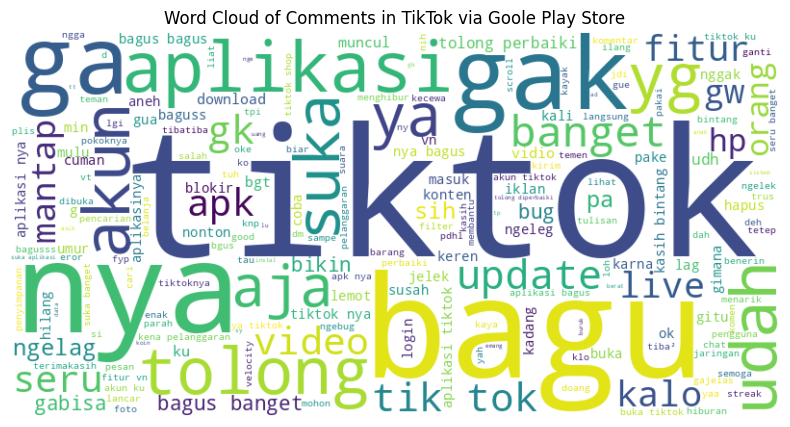

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text into a single string for the word cloud
all_text = ' '.join(output_df['cleaned_text'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Comments in TikTok via Goole Play Store")
plt.show()

### **Mencari Frekuensi yang Paling Sering Muncul** ###

         Word  Frequency
2      tiktok       2660
88      bagus       1962
37        nya       1513
86   aplikasi       1055
114      akun       1017
44     tolong        922
43        gak        835
60     banget        818
62         ga        759
130      suka        633
139        ya        589
375      udah        555
19         yg        511
34      fitur        466
134       apk        449
0      update        449
159       aja        442
35      video        423
41       live        418
11       seru        417


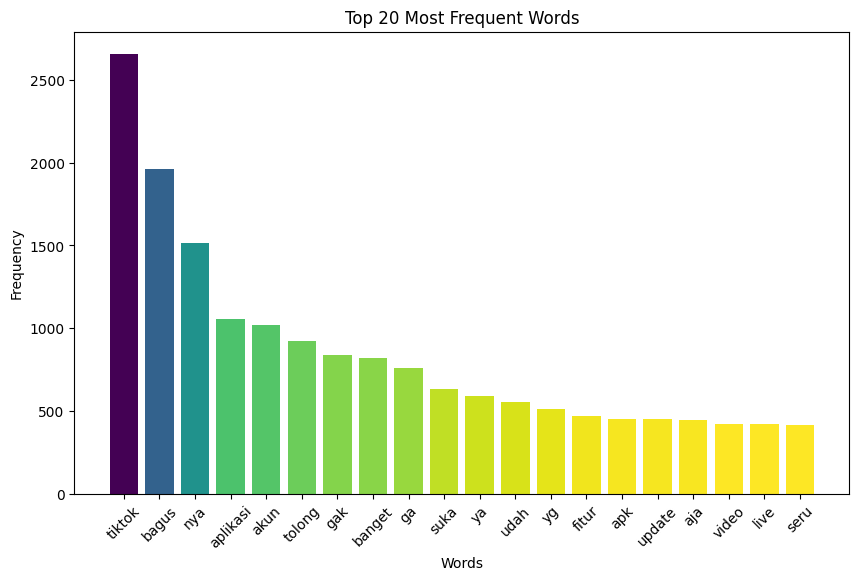

In [13]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import viridis_r
from matplotlib.colors import Normalize

# Split all cleaned text into individual words
all_words = ' '.join(output_df['cleaned_text']).split()

# Count the frequency of each word
word_counts = Counter(all_words)

# Convert the counts to a DataFrame for easier analysis
word_freq_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

# Display the top 20 most frequent words
print(word_freq_df.head(20))

# Prepare inverted viridis colormap
top_words = word_freq_df.head(20)
norm = Normalize(vmin=min(top_words['Frequency']), vmax=max(top_words['Frequency']))
colors = [viridis_r(norm(value)) for value in top_words['Frequency']]

# Show a bar plot of the top 20 most frequent words with inverted viridis
plt.figure(figsize=(10, 6))
plt.bar(top_words['Word'], top_words['Frequency'], color=colors)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45)
plt.show()

### **TF-IDF Feature Extraction dengan Porter Stemming untuk NLP / Analisis Sentimen** ###

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem.porter import PorterStemmer

# 1. Initialize the stemmer
porter = PorterStemmer()

# 2. Define the tokenizer function
def tokenizer_porter(text):
    return [porter.stem(word) for word in text.split()]

# 3. Define TF-IDF vectorizer
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        tokenizer=tokenizer_porter,
                        token_pattern=None,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# Fit and transform your cleaned text
tfidf_matrix = tfidf.fit_transform(output_df['cleaned_text'])
print(tfidf_matrix.shape)

(10000, 9183)


### **TF-IDF Feature Extraction untuk Klasifikasi Sentimen** ###

In [15]:

from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Membuat kolom label 'sentiment' berdasarkan 'score'
df_filtered_columns['sentiment'] = df_filtered_columns['score'].apply(lambda x: 1 if x > 3 else 0)

# 2. Inisialisasi TF-IDF Vectorizer (menggunakan default tokenizer)
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# 3. Transformasi teks yang sudah dibersihkan (cleaned_text) menjadi matriks fitur (X)
X = tfidf.fit_transform(df_filtered_columns['cleaned_text'])

# 4. Target variabel (Y)
y = df_filtered_columns['sentiment']

print("Dimensi fitur X:", X.shape)
print("Dimensi target y:", y.shape)

Dimensi fitur X: (10000, 9291)
Dimensi target y: (10000,)


### **Data Splitting / Train-Test Split** ###

In [16]:

from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

Jumlah data training: 8000
Jumlah data testing: 2000


### **Model Logistic Regression** ###

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Inisialisasi model Logistic Regression
model = LogisticRegression(class_weight='balanced')

# 2. Melatih (Training) model menggunakan data train
model.fit(X_train, y_train)

# 3. Memprediksi data test
y_pred = model.predict(X_test)

# 4. Menghitung dan menampilkan Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")

# Menampilkan laporan klasifikasi lengkap
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Akurasi Model: 81.55%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.84      0.79       845
    Positive       0.87      0.80      0.83      1155

    accuracy                           0.82      2000
   macro avg       0.81      0.82      0.81      2000
weighted avg       0.82      0.82      0.82      2000



In [19]:
def predict_sentiment(text):
    # Preprocess teks menggunakan fungsi 'preprocess_text' yang sudah kamu buat di awal
    cleaned_input = preprocess_text(text)

    # Ubah teks ke dalam format TF-IDF
    vectorized_input = tfidf.transform([cleaned_input])

    # Lakukan prediksi
    prediction = model.predict(vectorized_input)

    # Kembalikan hasil berupa string
    return "Positive" if prediction[0] == 1 else "Negative"

# Mari kita uji dengan kalimat baru!
test_sentence_1 = "aplikasi bagus"
test_sentence_2 = "semakin diupdate semakin ngelag"

print(f"Review: '{test_sentence_1}'\nPrediksi: {predict_sentiment(test_sentence_1)}\n")
print(f"Review: '{test_sentence_2}'\nPrediksi: {predict_sentiment(test_sentence_2)}")

Review: 'aplikasi bagus'
Prediksi: Positive

Review: 'semakin diupdate semakin ngelag'
Prediksi: Negative


### **Prediksi Data** ###

In [20]:
# Prediksi seluruh data matriks TF-IDF (X)
all_predictions = model.predict(X)

# Masukkan hasil prediksi ke dalam dataframe
df_filtered_columns['predicted_sentiment'] = all_predictions

# Mapping angka (1, 0) kembali menjadi teks agar mudah dibaca pada grafik nanti
df_filtered_columns['sentiment_label'] = df_filtered_columns['predicted_sentiment'].map({1: 'Positive', 0: 'Negative'})

# Tampilkan 5 baris pertama untuk mengecek hasilnya
df_filtered_columns[['content', 'score', 'sentiment_label']].head()

,content,score,sentiment_label
0,semakin di update semakin ngeleg,3,Negative
1,tiktok alay,1,Negative
2,"assalamualaikum google, hallo tik tok semoga k...",5,Positive
3,cara VN gimana nanya doang plssss aku pengen v...,4,Positive
4,fitur video offline nya tidak ada lgi?,4,Negative


### **Visualisasi Distribusi Prediksi Sentimen** ###

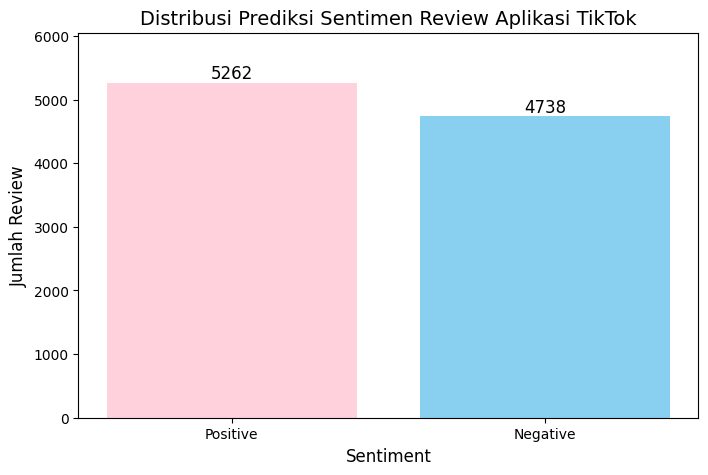

In [24]:
import matplotlib.pyplot as plt

# Hitung jumlah masing-masing sentimen
sentiment_counts = df_filtered_columns['sentiment_label'].value_counts()

# Membuat Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['#FFD1DC', '#89CFF0']) # Hijau & Merah

# Menambahkan judul dan label sumbu
plt.title('Distribusi Prediksi Sentimen Review Aplikasi TikTok', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)

# Menambahkan angka (label) di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=12)

# Tampilkan grafik
plt.ylim(0, max(sentiment_counts.values) + max(sentiment_counts.values)*0.15) # Memberi ruang kosong di atas bar
plt.show()
